# Image Reconstruction Using Sparse Fourier Sampling (Interferometry)

This project models how images can be reconstructed from incomplete frequency data, simulating the behaviour of an interferometric imaging system.

# The Workflow 
1. Analyse the spatial frequency content of an image
2. Simulate partial sampling of Fourier space (uv-plane)
3. Reconstruct the image and evaluate information loss

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

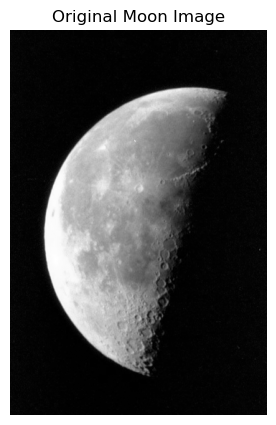

In [11]:
moon = plt.imread('moon-1.tif')
Ly, Lx = moon.shape

plt.figure(figsize=(5,5))
plt.imshow(moon, cmap='gray')
plt.title("Original Moon Image")
plt.axis('off')
plt.show()

In [12]:
F_moon = np.fft.fftshift(np.fft.fft2(moon))
power_spectrum = np.abs(F_moon)**2

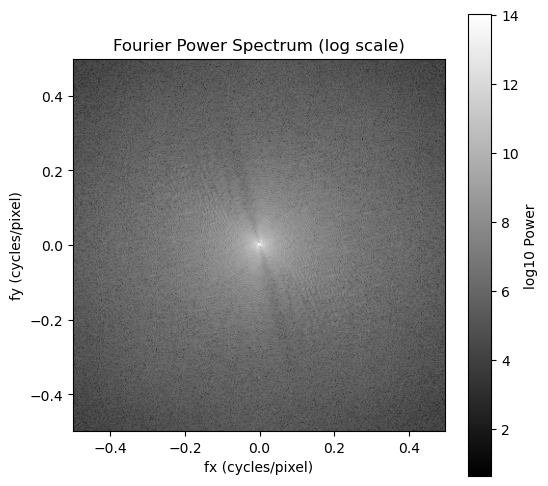

In [13]:
fx = np.fft.fftshift(np.fft.fftfreq(Lx))
fy = np.fft.fftshift(np.fft.fftfreq(Ly))

plt.figure(figsize=(6,6))
plt.imshow(np.log10(power_spectrum + 1),
           extent=[fx.min(), fx.max(), fy.min(), fy.max()],
           origin='lower', cmap='gray')
plt.xlabel('fx (cycles/pixel)')
plt.ylabel('fy (cycles/pixel)')
plt.title('Fourier Power Spectrum (log scale)')
plt.colorbar(label='log10 Power')
plt.show()

## Frequency Domain Insight

The Fourier transform reveals that most energy is concentrated at low spatial frequencies (centre), corresponding to large-scale brightness variations. Higher frequencies encode fine surface detail such as edges and craters.

This representation forms the basis for interferometric imaging, where only partial frequency sampling is available.

In [14]:
def fillUVplane(x, y, Lx_uv=358, Ly_uv=537):
    Fx = np.arange(-Lx_uv//2, Lx_uv//2)
    Fy = np.arange(-(Ly_uv-1)//2, (Ly_uv-1)//2 + 1)

    n = len(x)
    bx, by = [], []

    for i in range(n):
        for j in range(i+1, n):
            bx.append(x[j] - x[i])
            by.append(y[j] - y[i])

    bx = np.array(bx + [-b for b in bx])
    by = np.array(by + [-b for b in by])

    uv = np.zeros((Ly_uv, Lx_uv))

    for i in range(len(bx)):
        idx_x = np.argmin(np.abs(Fx - bx[i]))
        idx_y = np.argmin(np.abs(Fy - by[i]))
        uv[idx_y, idx_x] = 1

    # keep DC component
    uv[Ly_uv//2, Lx_uv//2] = 1

    return uv

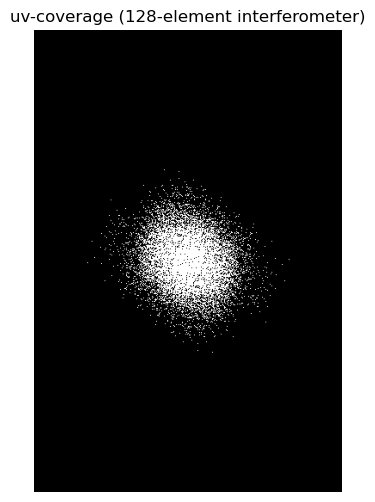

In [15]:
x = np.clip((20*np.random.randn(128) + Lx//2).astype(int), 1, Lx-1)
y = np.clip((20*np.random.randn(128) + Ly//2).astype(int), 1, Ly-1)

uv_128 = fillUVplane(x, y)

plt.figure(figsize=(6,6))
plt.imshow(uv_128, cmap='gray')
plt.title("uv-coverage (128-element interferometer)")
plt.axis('off')
plt.show()

In [16]:
scale_y = Ly / uv_128.shape[0]
scale_x = Lx / uv_128.shape[1]

uv_resized = zoom(uv_128, (scale_y, scale_x), order=0)
uv_resized = uv_resized[:Ly, :Lx]

In [17]:
M = np.fft.fftshift(np.fft.fft2(moon))
MC = M * uv_resized

moon_recon = np.fft.ifft2(np.fft.ifftshift(MC))
moon_recon = np.real(moon_recon)
moon_recon[moon_recon < 0] = 0

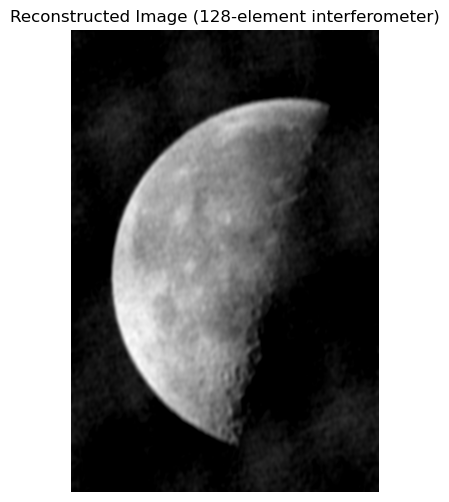

In [18]:
plt.figure(figsize=(6,6))
plt.imshow(moon_recon, cmap='gray')
plt.title("Reconstructed Image (128-element interferometer)")
plt.axis('off')
plt.show()

## Key Insights

This project demonstrates how incomplete sampling of Fourier space limits image reconstruction. The interferometer only measures a subset of spatial frequencies, leading to loss of detail and reconstruction artefacts.

Image quality depends strongly on:
- Baseline distribution
- Frequency coverage
- Sampling density in the uv-plane

This mirrors real-world sensing systems, where measurement constraints and incomplete data must be accounted for in reconstruction and interpretation.